In [41]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append('..')
from configs import env
import exp_diversity as ed

rhos = [5, 1, 0.2, 0.04, 0.008, 0]
output_dir = "."

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
import exp_diversity as ed
from configs import env
def process_rho(rho: float, output_dir: str = "."):
    print(f"Processing rho={rho}...")
    model_name = "CE_rho" + str(rho)
    model_path = os.path.join(env.MODELS_ROOT, model_name)
    rdm_file_name = f"RDM_{model_name}.pt"
    rdm_file_path = os.path.join(model_path, rdm_file_name)
    
    if not os.path.exists(rdm_file_path):
        print(f"  Warning: RDM file not found at {rdm_file_path}")
        return
        
    try:
        rdm_file = torch.load(rdm_file_path)
        rdms_upper = np.array(rdm_file['rdms_upper'])
        print(f"  Loaded RDM file with shape {np.array(rdms_upper).shape}, for rho={rho}")
    except Exception as e:
        print(f"  Error loading RDM file {rdm_file_path}: {e}")
        return
    
    # --- 2. Load Diversity ---
    try:
        scalar, pw = ed.get_diversity_results_by_ensemble_name(model_name)
        print(f"  Loaded diversity results for {model_name} with scalar keys: {list(scalar.keys())} and pairwise keys: {list(pw.keys())}, for rho={rho}")
    except Exception as e:
        print(f"  Error getting diversity results for {model_name}: {e}")
        return

    if not pw:
        print(f"  No pairwise diversity results found for {model_name}")
        return
    
    # Convert to numpy and create DataFrame for RDMs
    df = pd.DataFrame({str(i): t.tolist() for i, t in enumerate(rdms_upper)})
    print(df.size)

    # Calculate RDM Consistency Matrix
    rdms_corr = df.corr()

    # --- 5. Flatten Data for Correlation Analysis ---
    consistency_mat = rdms_corr.to_numpy()
    rows, cols = np.triu_indices_from(consistency_mat, k=1)
    
    data = {
        "rdms_consistency": consistency_mat[rows, cols]
    }
    
    for metric_name, matrix in pw.items():
        mat_np = matrix.detach().cpu().numpy()  
        if mat_np.shape == consistency_mat.shape:
             data[metric_name] = mat_np[rows, cols]

    df_pairs = pd.DataFrame(data)
    
    # --- 6. Calculate Correlations ---
    spearman_corr = df_pairs.corr(method='spearman')
    pearson_corr = df_pairs.corr(method='pearson')
    
    # --- 7. Visualization (With Fixed Sorting) ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # We sort alphabetically to ensure consistent layout across different rho values
    sorted_idx = sorted(spearman_corr.columns)
        
    # Helper to plot with explicit order
    def plot_corr_heatmap(corr_df, title, ax, order_idx):
        # Reorder the dataframe to match the fixed index
        corr_df_sorted = corr_df.loc[order_idx, order_idx]
        
        sns.heatmap(corr_df_sorted, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", ax=ax)
        ax.set_title(title)

    # Plot Spearman
    plot_corr_heatmap(spearman_corr, f'Spearman Correlation Matrix (rho={rho})', axes[0], sorted_idx)
    
    # Plot Pearson (using the SAME sorted_idx as Spearman)
    plot_corr_heatmap(pearson_corr, f'Pearson Correlation Matrix (rho={rho})', axes[1], sorted_idx)
    
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, f"diversity_consistency_correlation_rho{rho}.png")
    plt.savefig(save_path)
    plt.close()
    print(f"  Saved plot to {save_path}")

In [43]:
# for rho in rhos:
#     process_rho(rho)

Very big variance across rhos. Does it make sense? Professor think it might be a "low variance trap"
Let's show the variance so that we can understand that

In [44]:
model_names = ["CE_rho" + str(rho) for rho in rhos]
divs = {model_name: ed.get_diversity_results_by_ensemble_name(model_name)[1] for model_name in model_names}
divs[model_names[0]]['q_statistic']

tensor([[1.0000, 0.9251, 0.9299, 0.9269, 0.9286, 0.9151, 0.9158, 0.9096, 0.9246,
         0.9268],
        [0.9251, 1.0000, 0.9273, 0.9293, 0.9323, 0.9059, 0.9248, 0.9117, 0.9232,
         0.9233],
        [0.9299, 0.9273, 1.0000, 0.9227, 0.9356, 0.9188, 0.9269, 0.9241, 0.9247,
         0.9207],
        [0.9269, 0.9293, 0.9227, 1.0000, 0.9153, 0.9191, 0.9250, 0.9056, 0.9326,
         0.9322],
        [0.9286, 0.9323, 0.9356, 0.9153, 1.0000, 0.8988, 0.9224, 0.9302, 0.9232,
         0.9126],
        [0.9151, 0.9059, 0.9188, 0.9191, 0.8988, 1.0000, 0.9006, 0.9153, 0.9208,
         0.9174],
        [0.9158, 0.9248, 0.9269, 0.9250, 0.9224, 0.9006, 1.0000, 0.9124, 0.9144,
         0.9336],
        [0.9096, 0.9117, 0.9241, 0.9056, 0.9302, 0.9153, 0.9124, 1.0000, 0.9187,
         0.9159],
        [0.9246, 0.9232, 0.9247, 0.9326, 0.9232, 0.9208, 0.9144, 0.9187, 1.0000,
         0.9238],
        [0.9268, 0.9233, 0.9207, 0.9322, 0.9126, 0.9174, 0.9336, 0.9159, 0.9238,
         1.0000]], dtype=tor

In [45]:
mat = divs[model_names[0]]['q_statistic'].numpy()
rows, cols = np.triu_indices_from(mat, k=1)
mat[rows, cols].std()

np.float64(0.008511959822645247)

In [46]:
metrics = divs[model_names[0]].keys()

def mat_into_mean_std(mat):
    rows, cols = np.triu_indices_from(mat, k=1)
    topvals = mat[rows, cols].numpy()
    return (topvals.mean(), topvals.std())

stds = {}
for model in divs:
    stds[model] = {}
    for name in metrics:
        _, std = mat_into_mean_std(divs[model][name])
        stds[model][name] = std

print(stds)

{'CE_rho5': {'q_statistic': np.float64(0.008511959822645247), 'double_fault': np.float64(0.002311036323576263), 'disagreement': np.float64(0.004495627505328557), 'interrater_agreement': np.float64(0.017670187681636418), 'correlation': np.float64(0.01754368202068515), 'iou_top_n': np.float64(0.05620671900385546)}, 'CE_rho1': {'q_statistic': np.float64(0.008315970855720728), 'double_fault': np.float64(0.002114341388275044), 'disagreement': np.float64(0.0035154993674397267), 'interrater_agreement': np.float64(0.018551189891684226), 'correlation': np.float64(0.018566873063469692), 'iou_top_n': np.float64(0.04816520789355604)}, 'CE_rho0.2': {'q_statistic': np.float64(0.008829875781881115), 'double_fault': np.float64(0.001646059267192743), 'disagreement': np.float64(0.00435622670566066), 'interrater_agreement': np.float64(0.01857848720488955), 'correlation': np.float64(0.01849205611526871), 'iou_top_n': np.float64(0.03531209043831739)}, 'CE_rho0.04': {'q_statistic': np.float64(0.005654884334

In [47]:
import polars as pl
df = (
    pl.from_dicts(
        [{"setting": setting, **metrics} for setting, metrics in stds.items()]
    )
    .select(["setting", *sorted(next(iter(stds.values())).keys())])
)
df

setting,correlation,disagreement,double_fault,interrater_agreement,iou_top_n,q_statistic
str,f64,f64,f64,f64,f64,f64
"""CE_rho5""",0.017544,0.004496,0.002311,0.01767,0.056207,0.008512
"""CE_rho1""",0.018567,0.003515,0.002114,0.018551,0.048165,0.008316
"""CE_rho0.2""",0.018492,0.004356,0.001646,0.018578,0.035312,0.00883
"""CE_rho0.04""",0.013676,0.002323,0.001457,0.013651,0.02345,0.005655
"""CE_rho0.008""",0.014444,0.004193,0.002515,0.014668,0.022231,0.006761
"""CE_rho0""",0.015422,0.002987,0.001862,0.015478,0.015841,0.006417


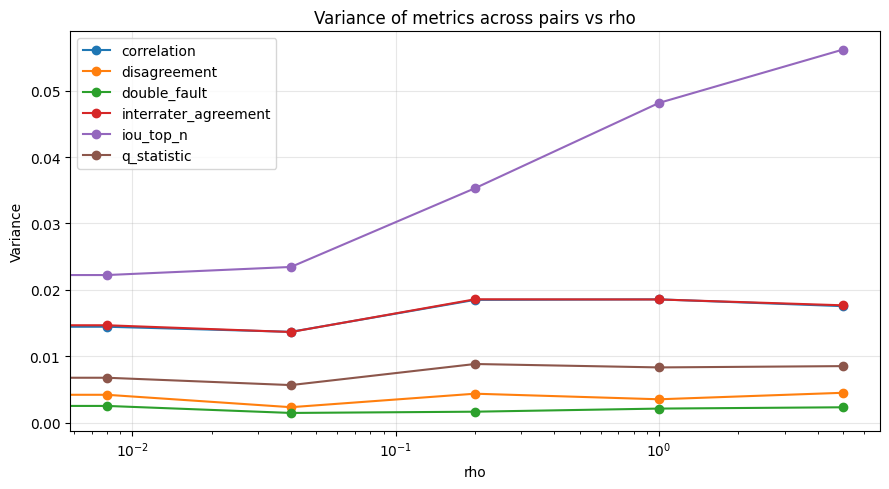

In [48]:
metric_cols = [c for c in df.columns if c != "setting"]

# 1) Extract numeric rho from the setting string (e.g. "CE_rho0.04" -> 0.04, "CE_rho5" -> 5.0)
df2 = df.with_columns(
    pl.col("setting")
      .str.extract(r"rho([0-9]*\.?[0-9]+)", 1)
      .cast(pl.Float64)
      .alias("rho")
).drop("setting")

# 2) Sort by rho so lines connect in the right order
df2 = df2.sort("rho")

# 3) Long/tidy form: columns [rho, metric, value]
long = df2.unpivot(index="rho", on=metric_cols, variable_name="metric", value_name="value")

# 4) Plot: one line per metric
plt.figure(figsize=(9, 5))
for metric, sub in long.group_by("metric", maintain_order=True):
    sub_pd = sub.sort("rho").to_pandas()
    plt.plot(sub_pd["rho"], sub_pd["value"], marker="o", label=metric)

plt.xscale("log")   # <- log x axis
plt.xlabel("rho")
plt.ylabel("Variance")
plt.title("Variance of metrics across pairs vs rho")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Low variance indeed. Now let's plot the means and stds

In [49]:
vals = {}
for model in divs:
    vals[model] = {}
    for name in metrics:
        mean, std = mat_into_mean_std(divs[model][name])
        vals[model][name] = (mean,std)

vals

{'CE_rho5': {'q_statistic': (np.float64(0.9209656087007654),
   np.float64(0.008511959822645247)),
  'double_fault': (np.float64(0.04736666666666667),
   np.float64(0.002311036323576263)),
  'disagreement': (np.float64(0.08256666666666666),
   np.float64(0.004495627505328557)),
  'interrater_agreement': (np.float64(0.4891394066064456),
   np.float64(0.017670187681636418)),
  'correlation': (np.float64(0.48971463860200576),
   np.float64(0.01754368202068515)),
  'iou_top_n': (np.float64(0.7014287153879801),
   np.float64(0.05620671900385546))},
 'CE_rho1': {'q_statistic': (np.float64(0.9203447077927123),
   np.float64(0.008315970855720728)),
  'double_fault': (np.float64(0.04744222222222221),
   np.float64(0.002114341388275044)),
  'disagreement': (np.float64(0.08273555555555555),
   np.float64(0.0035154993674397267)),
  'interrater_agreement': (np.float64(0.4887748635096568),
   np.float64(0.018551189891684226)),
  'correlation': (np.float64(0.4890486589446726),
   np.float64(0.0185668

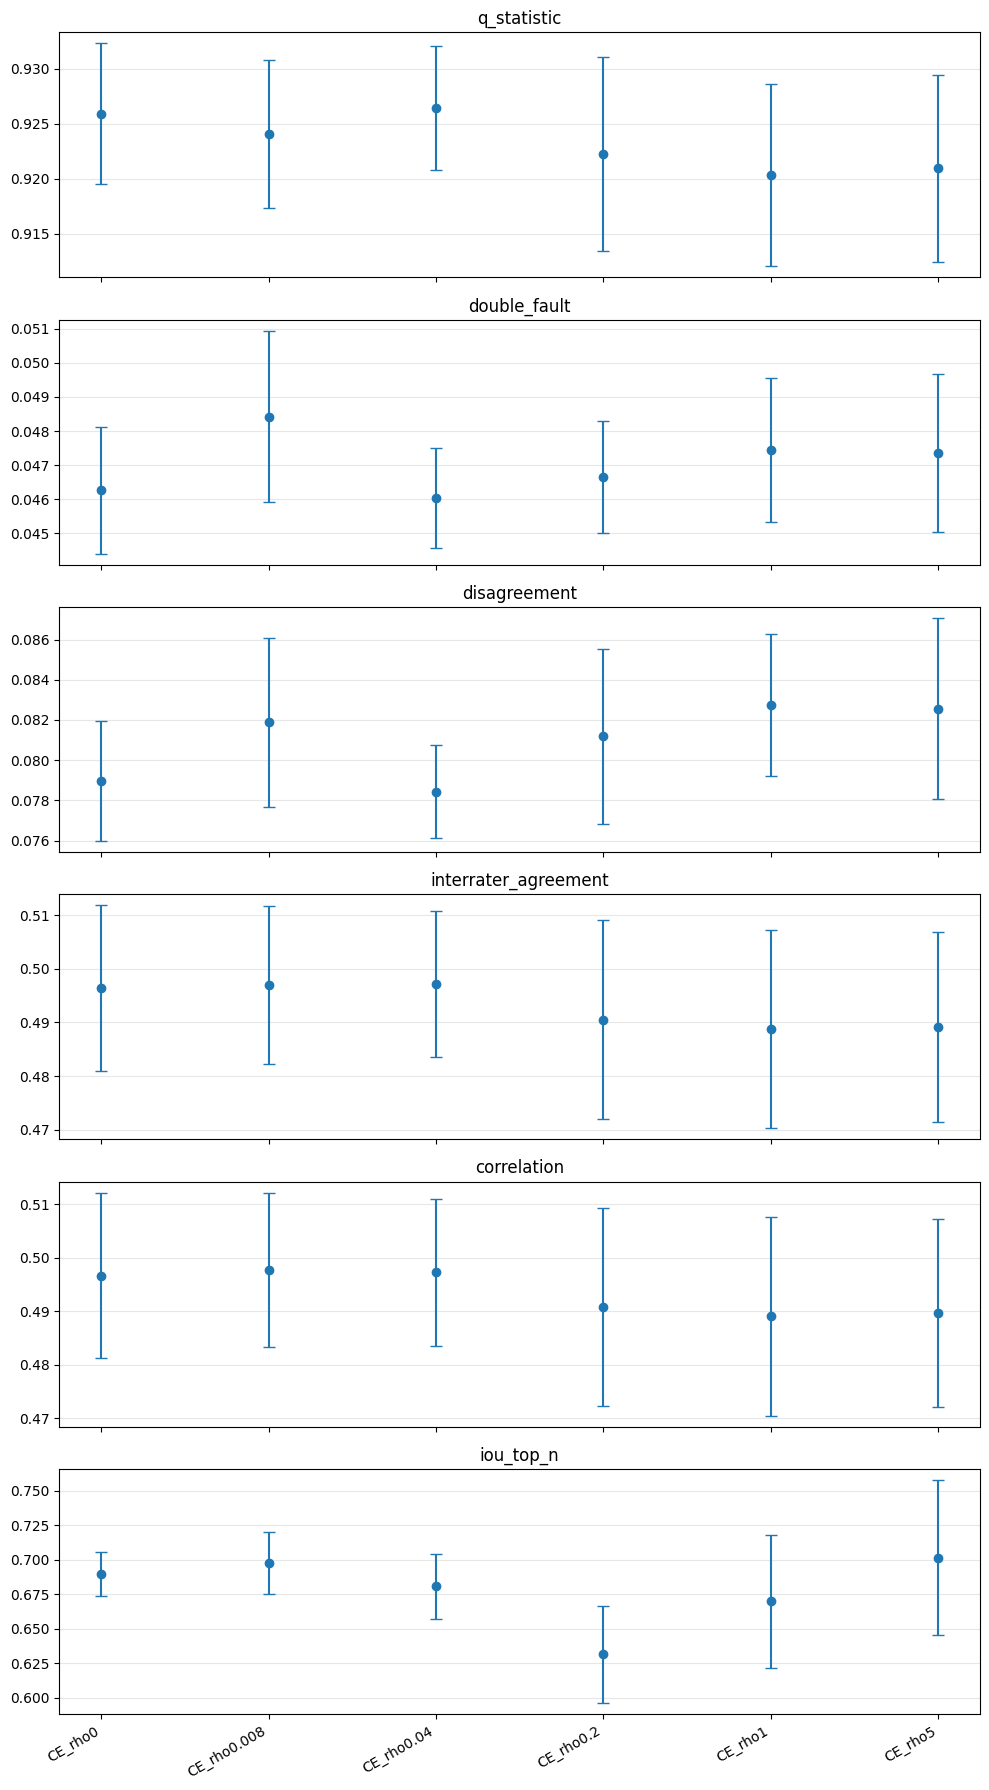

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# expects: vals[model][metric] = (mean_scalar, std_scalar)

metrics7 = list(metrics)
models = list(vals.keys())[::-1]

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10, 18), sharex=True)

x = np.arange(len(models))

for ax, metric in zip(axes, metrics7):
    means = np.array([float(vals[m][metric][0]) for m in models], dtype=float)
    stds  = np.array([float(vals[m][metric][1]) for m in models], dtype=float)

    ax.errorbar(
        x, means, yerr=stds,
        fmt="o", markersize=6, capsize=4, elinewidth=1.5
    )
    ax.set_title(metric)
    ax.grid(True, axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(models, rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:

def retrieve_upper_rdm(model_name):
    model_path = os.path.join(env.MODELS_ROOT, model_name)
    rdm_file_name = f"RDM_{model_name}.pt"
    rdm_file_path = os.path.join(model_path, rdm_file_name)
    rdm_file = torch.load(rdm_file_path)
    rdms_upper = np.array(rdm_file['rdms_upper'])
    df = pd.DataFrame({str(i): t.tolist() for i, t in enumerate(rdms_upper)})
    rdms_corr = df.corr()
    consistency_mat = rdms_corr.to_numpy()

retrieve_upper_rdm(model_names[0])
# divs = {model_name: ed.get_diversity_results_by_ensemble_name(model_name)[1] for model_name in model_names}
    

array([[0.01816046, 0.01336753, 0.01414245, ..., 0.01330322, 0.06311995,
        0.03824729],
       [0.00894946, 0.00583112, 0.01569003, ..., 0.00741702, 0.11698979,
        0.06669813],
       [0.04237127, 0.01906067, 0.05911314, ..., 0.0082022 , 0.6905782 ,
        0.5814228 ],
       ...,
       [0.0148353 , 0.00899941, 0.01973593, ..., 0.5572258 , 0.90153736,
        0.12261528],
       [0.00989509, 0.01861751, 0.02309841, ..., 0.04516745, 0.7426928 ,
        0.48800665],
       [0.00542712, 0.00958061, 0.01092917, ..., 0.02656424, 0.07706279,
        0.0185405 ]], shape=(10, 499500), dtype=float32)

In [77]:
per_rho_vals = {}

def retrieve_metrics_mean_std(rho: float, output_dir: str = "."):
    rho_key = float(np.asarray(rho))

    rho_name = str(rho_key) if rho_key % 1 != 0 else str(int(rho_key))
    model_name = "CE_rho" + rho_name
    model_path = os.path.join(env.MODELS_ROOT, model_name)
    rdm_file_name = f"RDM_{model_name}.pt"
    rdm_file_path = os.path.join(model_path, rdm_file_name)

    if not os.path.exists(rdm_file_path):
        print(f"  Warning: RDM file not found at {rdm_file_path}")
        return

    rdm_file = torch.load(rdm_file_path)
    rdms_upper = np.array(rdm_file["rdms_upper"])

    scalar, pw = ed.get_diversity_results_by_ensemble_name(model_name)
    if not pw:
        print(f"  No pairwise diversity results found for {model_name}")
        return

    df = pd.DataFrame({str(i): t.tolist() for i, t in enumerate(rdms_upper)})
    consistency_mat = df.corr().to_numpy()
    rows, cols = np.triu_indices_from(consistency_mat, k=1)

    data = {"rdms_consistency": consistency_mat[rows, cols]}
    for metric_name, matrix in pw.items():
        mat_np = matrix.detach().cpu().numpy()
        if mat_np.shape == consistency_mat.shape:
            data[metric_name] = mat_np[rows, cols]

    df_pairs = pd.DataFrame(data)

    cols_names = list(df_pairs.columns)
    means = df_pairs.to_numpy(dtype=float).mean(axis=0)
    stds  = df_pairs.to_numpy(dtype=float).std(axis=0, ddof=1)

    per_rho_vals[rho_key] = pd.Series(
        {c: (float(mu), float(sd)) for c, mu, sd in zip(cols_names, means, stds)}
    )



for rho in rhos:
    retrieve_metrics_mean_std(rho)

per_rho_vals

{5.0: rdms_consistency          (0.48818415237872986, 0.14456221012098408)
 q_statistic               (0.9209656087007654, 0.008608143212580101)
 double_fault            (0.04736666666666667, 0.0023371505572540095)
 disagreement             (0.08256666666666666, 0.004546427168667722)
 interrater_agreement       (0.4891394066064456, 0.01786985715698842)
 correlation               (0.48971463860200576, 0.01774192200816717)
 iou_top_n                  (0.7014287153879801, 0.05684184333286417)
 dtype: object,
 1.0: rdms_consistency           (0.47531415007315975, 0.1218729354556942)
 q_statistic               (0.9203447077927123, 0.008409939610762867)
 double_fault            (0.04744222222222221, 0.0021382330097630626)
 disagreement             (0.08273555555555555, 0.003555223785026218)
 interrater_agreement       (0.4887748635096568, 0.01876081451025449)
 correlation                (0.4890486589446726, 0.01877667489864561)
 iou_top_n                 (0.6697862797313267, 0.04870946480602

Saved: metrics_vs_rho_equal_spaced.png


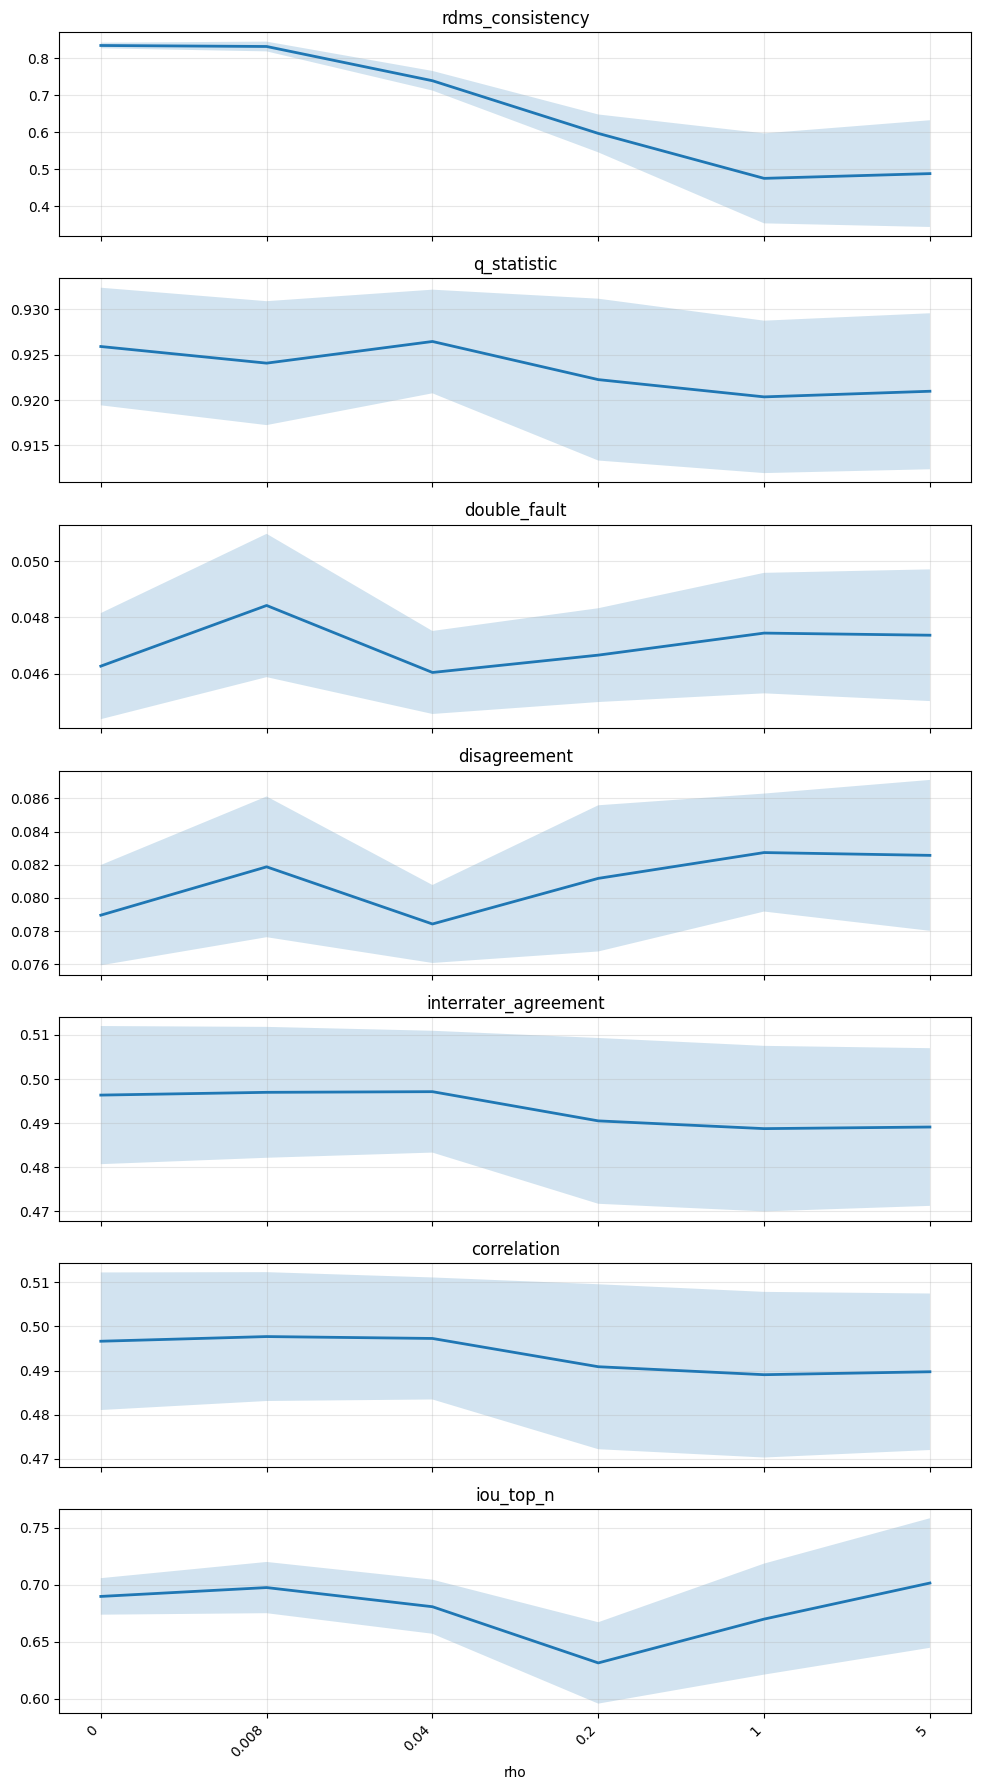

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# build tuples_df
tuples_df = pd.DataFrame.from_dict(per_rho_vals, orient="index")
tuples_df.index = tuples_df.index.astype(float)
tuples_df = tuples_df.sort_index()

means_df = tuples_df.map(lambda t: t[0]).astype(float)
stds_df  = tuples_df.map(lambda t: t[1]).astype(float)

rhos = tuples_df.index.to_numpy(dtype=float)

# equally spaced x positions
x = np.arange(len(rhos))

metrics7 = list(means_df.columns)[:7]
fig, axes = plt.subplots(len(metrics7), 1, figsize=(10, 18), sharex=True)
if len(metrics7) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics7):
    y = means_df[metric].to_numpy()
    s = stds_df[metric].to_numpy()

    ax.plot(x, y, linewidth=2)
    ax.fill_between(x, y - s, y + s, alpha=0.2)
    ax.set_title(metric)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("rho")
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"{v:g}" for v in rhos], rotation=45, ha="right")  # optional formatting

import os
from pathlib import Path
out_dir = Path(".")  # current working directory
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"metrics_vs_rho_equal_spaced.png"

fig.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.tight_layout()
plt.show()